In [2]:
import pandas as pd
import numpy as np
from matplotlib import cm
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# **Volatilidad, Precio y Tiempo**

In [3]:
def stock_finance(ticker='NVDA',periodo='2y'):
    stock=ticker
    df = yf.download(stock, period=periodo, interval="1d")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df['Returns'] = df['Close'].pct_change().dropna()
    df["MA_10"] = df["Close"].rolling(10).mean()
    df["MA_20"] = df["Close"].rolling(20).mean()
    df["MA_50"]=df["Close"].rolling(50).mean()
    df['MA_100']=df['Close'].rolling(100).mean()
    df["Volatility"] = df["Returns"].rolling(20).std()
    df["Cumulative_Returns"] = (1 + df["Returns"]).cumprod()
    df["Volume_Norm"] = df["Volume"] / df["Volume"].max()
    df['Stock']=stock
    df["BB_Middle"] = df["Close"].rolling(20).mean()
    df["BB_Std"] = df["Close"].rolling(20).std()
    df["BB_Upper"] = df["BB_Middle"] + 2 * df["BB_Std"]
    df["BB_Lower"] = df["BB_Middle"] - 2 * df["BB_Std"]
    return df

def compute_rsi(data, window=14):
    delta = data.diff()

    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()

    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

def compute_macd(df, fast=12, slow=26, signal=9):
    ema_fast = df["Close"].ewm(span=fast, adjust=False).mean()
    ema_slow = df["Close"].ewm(span=slow, adjust=False).mean()

    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    hist = macd - signal_line

    return macd, signal_line, hist

In [4]:
df=stock_finance(ticker='SPY',periodo='2y')
df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = compute_macd(df)
df["RSI"] = compute_rsi(df["Close"], 14)
df["Buy_Signal"] = (df["RSI"] < 30) & (df["Close"] < df["BB_Lower"])
df["Sell_Signal"] = (df["RSI"] > 70) & (df["Close"] > df["BB_Upper"])
df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Returns,MA_10,MA_20,MA_50,MA_100,...,BB_Middle,BB_Std,BB_Upper,BB_Lower,MACD,MACD_Signal,MACD_Hist,RSI,Buy_Signal,Sell_Signal
Date,,,,,,,,,,,,,,,,,,,,,
2024-06-13,529.562073,530.421170,526.770037,530.245454,44760900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,NaN,False,False
2024-06-14,529.884277,529.913534,527.023838,528.029395,40089900,0.000608,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.025703,0.005141,0.020562,NaN,False,False
2024-06-17,534.101501,535.497579,528.741947,529.200811,55839500,0.007959,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.381964,0.080505,0.301459,NaN,False,False
2024-06-18,535.458618,535.585534,533.740424,534.160200,41376400,0.002541,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.764994,0.217403,0.547591,NaN,False,False
2024-06-20,534.003967,537.049835,532.227201,536.385998,70328200,-0.002717,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.940330,0.361988,0.578341,NaN,False,False


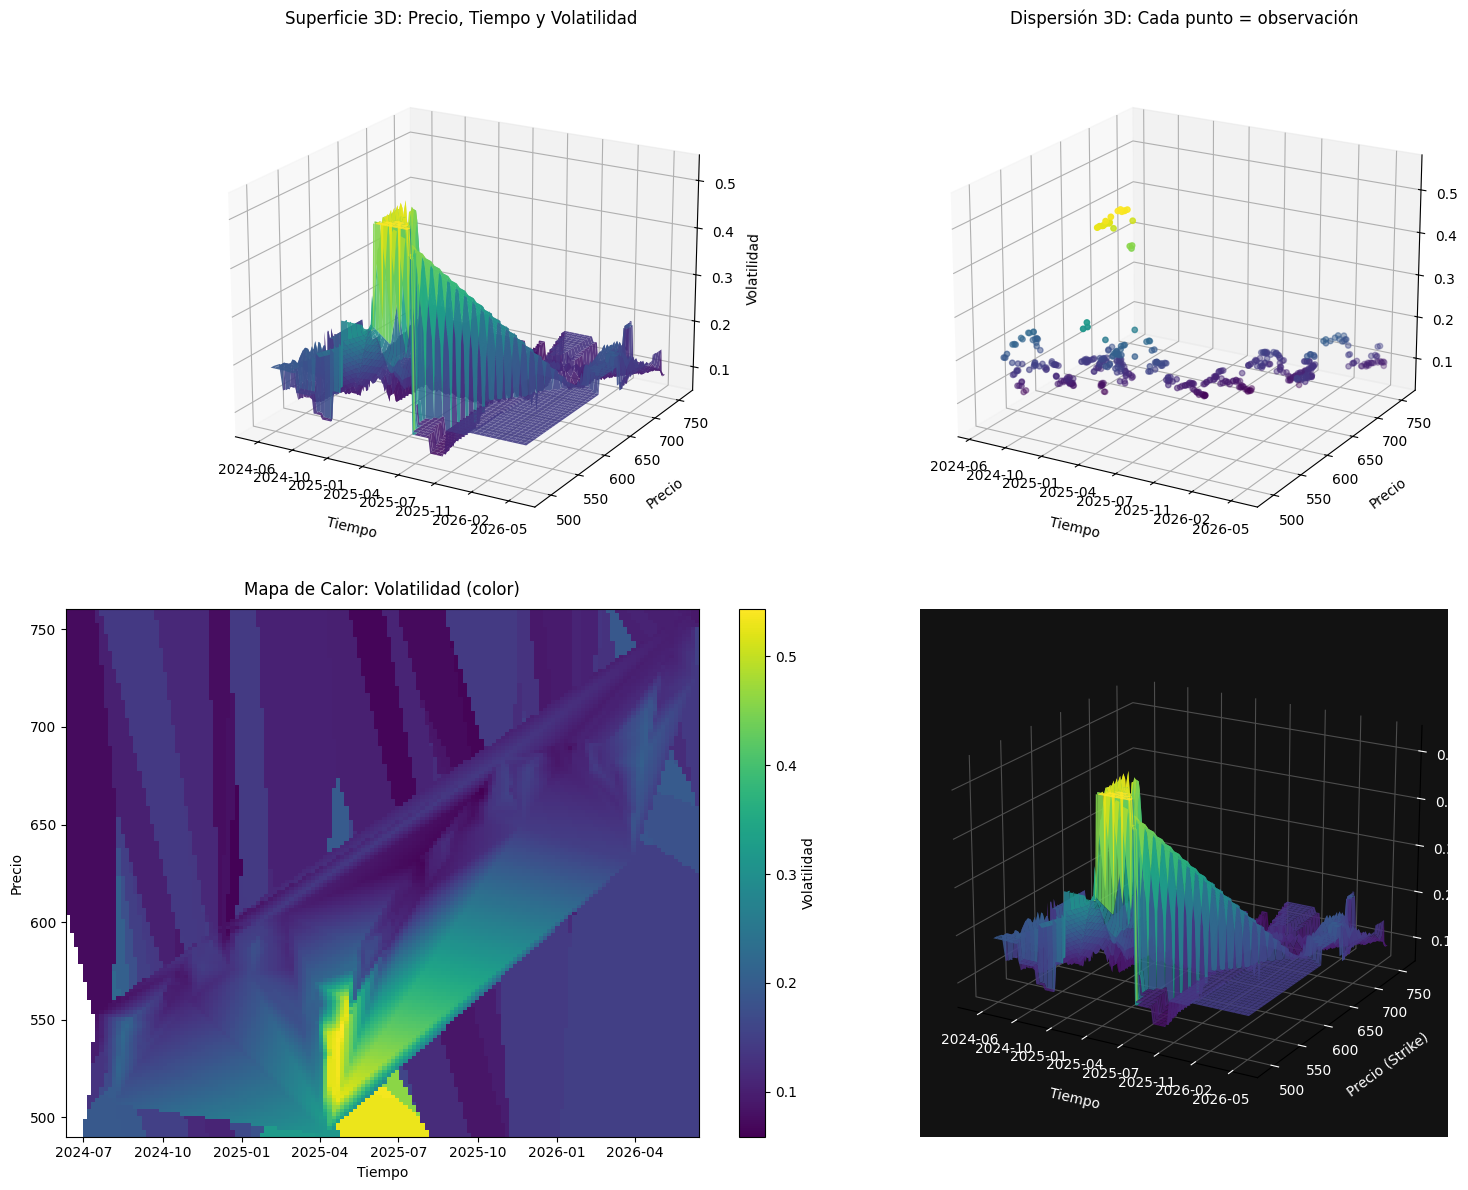

In [5]:
ventana_dias = 20
df["Volatility"] = df["Returns"].rolling(window=ventana_dias).std() * np.sqrt(252)


# --- 3. CREACIÓN DE LA MALLA (MESHGRID) MEDIANTE INTERPOLACIÓN ---
# Las superficies 3D requieren una cuadrícula perfecta (X, Y).
# Como los precios de mercado fluctúan, interpolamos los datos reales en una malla regular.
num_puntos = 150
x_fechas = mdates.date2num(df.index)
y_precios = df["Close"].values
z_volatilidad = df["Volatility"].values

# Creamos los rangos del espacio bidimensional
x_grid = np.linspace(x_fechas.min(), x_fechas.max(), num_puntos)
y_grid = np.linspace(y_precios.min(), y_precios.max(), num_puntos)
X_malla, Y_malla = np.meshgrid(x_grid, y_grid)

# Interpolamos la volatilidad sobre la malla generada
Z_malla = griddata(
    (x_fechas, y_precios), z_volatilidad, (X_malla, Y_malla), method="linear"
)
# Rellenamos posibles valores fuera del rango con el vecino más cercano
Z_malla = np.where(
    np.isnan(Z_malla),
    griddata(
        (x_fechas, y_precios),
        z_volatilidad,
        (X_malla, Y_malla),
        method="nearest",
    ),
    Z_malla,
)

# --- 4. DISEÑO DE LAS CUATRO GRÁFICAS ---
plt.style.use("default")
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor("white")

# Gráfica 1: Superficie 3D
ax1 = fig.add_subplot(221, projection="3d")
surf1 = ax1.plot_surface(
    X_malla, Y_malla, Z_malla, cmap="viridis", edgecolor="none", alpha=0.9
)
ax1.set_title("Superficie 3D: Precio, Tiempo y Volatilidad", fontsize=12, pad=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.set_xlabel("Tiempo", labelpad=10)
ax1.set_ylabel("Precio", labelpad=10)
ax1.set_zlabel("Volatilidad", labelpad=5)

# Gráfica 2: Dispersión 3D (Observaciones reales sin interpolar)
ax2 = fig.add_subplot(222, projection="3d")
scatter = ax2.scatter(
    x_fechas, y_precios, z_volatilidad, c=z_volatilidad, cmap="viridis", s=15
)
ax2.set_title("Dispersión 3D: Cada punto = observación", fontsize=12, pad=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.set_xlabel("Tiempo", labelpad=10)
ax2.set_ylabel("Precio", labelpad=10)
ax2.set_zlabel("Volatilidad", labelpad=5)

# Gráfica 3: Mapa de Calor
ax3 = fig.add_subplot(223)
heatmap = ax3.pcolormesh(
    mdates.num2date(x_grid), y_grid, Z_malla, cmap="viridis", shading="auto"
)
ax3.set_title("Mapa de Calor: Volatilidad (color)", fontsize=12, pad=10)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax3.set_xlabel("Tiempo")
ax3.set_ylabel("Precio")
fig.colorbar(heatmap, ax=ax3, label="Volatilidad")

# ==========================================
# 4. SUPERFICIE DE VOLATILIDAD (ESTILO OPCIONES)
# ==========================================
ax4 = fig.add_subplot(224, projection="3d")
ax4.set_facecolor("#121212")  # Fondo oscuro del panel
surf2 = ax4.plot_surface(
    X_malla, Y_malla, Z_malla, cmap="viridis", edgecolor="none", alpha=0.9
)
ax4.set_title(
    "Superficie de Volatilidad (estilo opciones)",
    fontsize=12,
    pad=10,
    color="white",
)

# CORRECCIÓN AQUÍ: Se eliminó el prefijo 'w_' para compatibilidad con Matplotlib moderno
ax4.xaxis.set_pane_color((0.07, 0.07, 0.07, 1.0))
ax4.yaxis.set_pane_color((0.07, 0.07, 0.07, 1.0))
ax4.zaxis.set_pane_color((0.07, 0.07, 0.07, 1.0))

# Cambiar el color de las líneas de la cuadrícula trasera a gris
ax4.xaxis._axinfo["grid"]["color"] = (0.3, 0.3, 0.3, 1.0)
ax4.yaxis._axinfo["grid"]["color"] = (0.3, 0.3, 0.3, 1.0)
ax4.zaxis._axinfo["grid"]["color"] = (0.3, 0.3, 0.3, 1.0)

# Configurar textos y números en blanco para que contrasten con el fondo oscuro
ax4.tick_params(colors="white")
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax4.set_xlabel("Tiempo", color="white", labelpad=10)
ax4.set_ylabel("Precio (Strike)", color="white", labelpad=10)
ax4.set_zlabel("Volatilidad", color="white", labelpad=5)

# Ajustar ángulos de visión
for ax in [ax1, ax2, ax4]:
    ax.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()

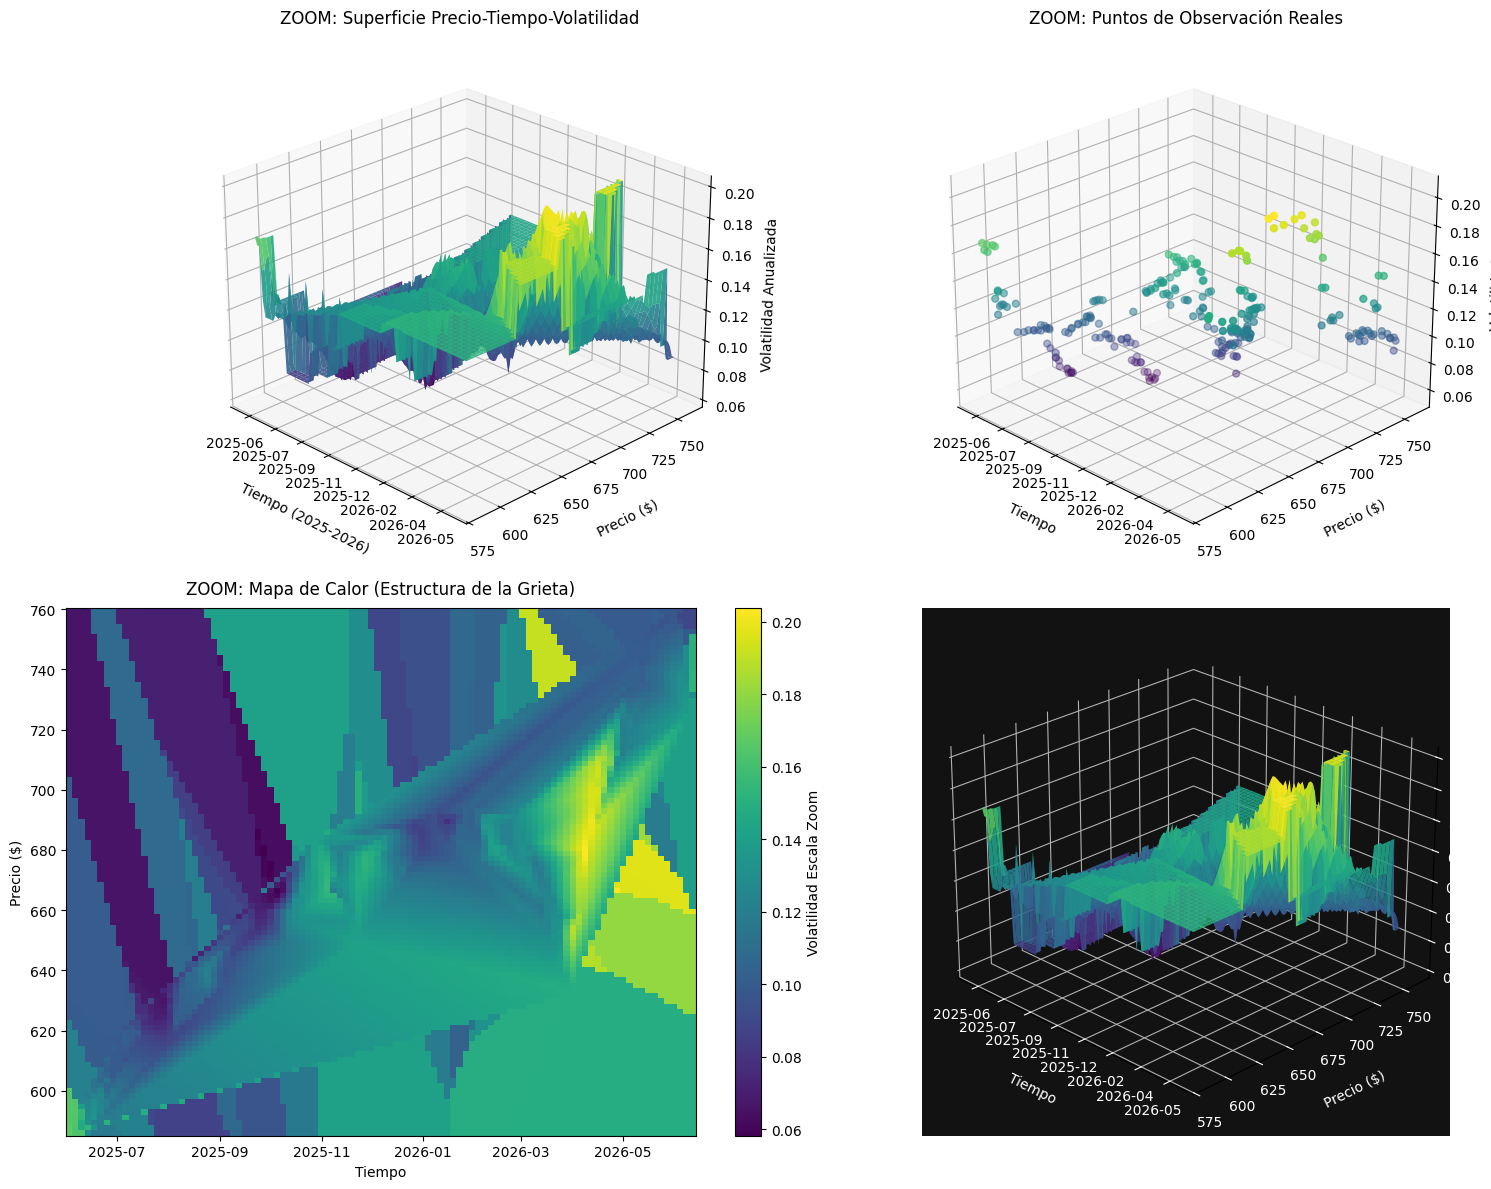

In [6]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import griddata

# ==========================================
# 1. FILTRO DE CORTE: EL ZOOM TEMPORAL (Jun 2025 - Mar 2026)
# ==========================================
df.index = pd.to_datetime(df.index)

# Creamos la máscara para aislar el rango exacto del estallido
# zoom_mask = (df.index >= "2025-06-01") & (df.index <= "2026-03-31")
zoom_mask = (df.index >= "2025-06-01") & (df.index <= "2026-06-30")
df_zoom = df[zoom_mask].copy()

# Guardamos las variables reales del zoom
x_fechas = mdates.date2num(df_zoom.index)
y_precios = df_zoom["Close"].values
z_volatilidad = df_zoom["Volatility"].values

# ==========================================
# 2. RECALCULAR LA MALLA DE ALTA RESOLUCIÓN
# ==========================================
# Subimos a 100 puntos para que la superficie sea súper fluida en el zoom
num_puntos = 100  
x_grid = np.linspace(x_fechas.min(), x_fechas.max(), num_puntos)
y_grid = np.linspace(y_precios.min(), y_precios.max(), num_puntos)
X_malla, Y_malla = np.meshgrid(x_grid, y_grid)

# Interpolación lineal + ajuste de bordes
Z_malla = griddata(
    (x_fechas, y_precios), z_volatilidad, (X_malla, Y_malla), method="linear"
)
Z_malla = np.where(
    np.isnan(Z_malla),
    griddata(
        (x_fechas, y_precios),
        z_volatilidad,
        (X_malla, Y_malla),
        method="nearest",
    ),
    Z_malla,
)

# ==========================================
# 3. RENDERIZADO DEL PANEL 2x2 CON ZOOM
# ==========================================
plt.style.use("default")
fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor("white")

# Gráfica 1: Superficie 3D (Zoom)
ax1 = fig.add_subplot(221, projection="3d")
surf1 = ax1.plot_surface(
    X_malla, Y_malla, Z_malla, cmap="viridis", edgecolor="none", alpha=0.9
)
ax1.set_title("ZOOM: Superficie Precio-Tiempo-Volatilidad", fontsize=12, pad=10)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax1.set_xlabel("Tiempo (2025-2026)", labelpad=10)
ax1.set_ylabel("Precio ($)", labelpad=10)
ax1.set_zlabel("Volatilidad Anualizada", labelpad=5)

# Gráfica 2: Dispersión 3D (Zoom de observaciones)
ax2 = fig.add_subplot(222, projection="3d")
scatter = ax2.scatter(
    x_fechas, y_precios, z_volatilidad, c=z_volatilidad, cmap="viridis", s=25
)  # Aumentamos tamaño de puntos para verlos mejor
ax2.set_title("ZOOM: Puntos de Observación Reales", fontsize=12, pad=10)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax2.set_xlabel("Tiempo", labelpad=10)
ax2.set_ylabel("Precio ($)", labelpad=10)
ax2.set_zlabel("Volatilidad", labelpad=5)

# Gráfica 3: Mapa de Calor (Zoom)
ax3 = fig.add_subplot(223)
heatmap = ax3.pcolormesh(
    mdates.num2date(x_grid), y_grid, Z_malla, cmap="viridis", shading="auto"
)
ax3.set_title("ZOOM: Mapa de Calor (Estructura de la Grieta)", fontsize=12, pad=10)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax3.set_xlabel("Tiempo")
ax3.set_ylabel("Precio ($)")
fig.colorbar(heatmap, ax=ax3, label="Volatilidad Escala Zoom")

# Gráfica 4: Superficie Estilo Opciones (Fondo Oscuro Zoom)
ax4 = fig.add_subplot(224, projection="3d")
ax4.set_facecolor("#121212")
surf2 = ax4.plot_surface(
    X_malla, Y_malla, Z_malla, cmap="viridis", edgecolor="none", alpha=0.9
)
ax4.set_title(
    "ZOOM: Estilo Opciones (Fondo Oscuro)", fontsize=12, pad=10, color="white"
)
ax4.xaxis.set_pane_color((0.07, 0.07, 0.07, 1.0))
ax4.yaxis.set_pane_color((0.07, 0.07, 0.07, 1.0))
ax4.zaxis.set_pane_color((0.07, 0.07, 0.07, 1.0))
ax4.tick_params(colors="white")
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax4.set_xlabel("Tiempo", color="white", labelpad=10)
ax4.set_ylabel("Precio ($)", color="white", labelpad=10)
ax4.set_zlabel("Volatilidad", color="white", labelpad=5)

# Ajuste fino de la cámara para maximizar la perspectiva del pico
for ax in [ax1, ax2, ax4]:
    ax.view_init(elev=25, azim=-45)

plt.tight_layout()
plt.show()


In [30]:
# Código rápido para animar la rotación de tu gráfica y guardarla
from matplotlib.animation import FuncAnimation

def animar(angulo):
    ax1.view_init(elev=25, azim=angulo)

# Hace girar el gráfico 360 grados
ani = FuncAnimation(fig, animar, frames=np.arange(0, 360, 2), interval=50)
ani.save('superficie_volatilidad.gif', writer='imagemagick')


MovieWriter imagemagick unavailable; using Pillow instead.


In [8]:
import matplotlib.dates as mdates
import plotly.graph_objects as go

# 1. CONVERSIÓN CRÍTICA: Plotly necesita fechas reales (strings o datetime),
# no los números internos de Matplotlib (mdates).
# Convertimos solo la primera fila de la malla X (que representa el vector de tiempo)
fechas_reales = [mdates.num2date(num).strftime("%Y-%m-%d") for num in X_malla[0]]

# 2. CREAR LA SUPERFICIE 3D CON GRAPH OBJECTS
fig = go.Figure(
    data=[
        go.Surface(
            x=fechas_reales,  # Eje X: Fechas legibles
            y=Y_malla[
                :, 0
            ],  # Eje Y: Vector de Precios (tomamos una columna de la malla)
            z=Z_malla,  # Eje Z: Matriz bidimensional de Volatilidad
            colorscale="Viridis",  # Mismo mapa de color que Matplotlib
            colorbar=dict(title="Volatilidad Anualizada"),
        )
    ]
)

# 3. CONFIGURAR ETIQUETAS, TÍTULO Y DISEÑO INTERACTIVO
fig.update_layout(
    title="ZOOM: Superficie Precio-Tiempo-Volatilidad (Interactiva)",
    scene=dict(
        xaxis=dict(
            title="Tiempo (2025-2026)",
            type="category",  # Mantiene el orden cronológico de las fechas
        ),
        yaxis=dict(title="Precio ($)"),
        zaxis=dict(title="Volatilidad Anualizada"),
    ),
    margin=dict(l=0, r=0, b=0, t=40),  # Maximiza el espacio del gráfico
    width=900,
    height=700,
)

# 4. MOSTRAR EN EL NAVEGADOR O JUPYTER NOTEBOOK
fig.show()

# Opcional: Descomenta la siguiente línea si quieres guardarlo como una página web independiente (.html)
fig.write_html("superficie_spy_zoom.html")


# **Modelo de Volatilidad**

In [ ]:
from arch import arch_model

# Modelo arch 1

df["Returns_Pct"] = df["Returns"] * 100
df_model = df["Returns_Pct"].dropna()

# 2. Especificar el modelo ARCH(1)
# p=1 indica el orden del componente ARCH
modelo_arch = arch_model(
    df_model, vol="ARCH", p=1, dist="normal", rescale=False
)
resultado_arch = modelo_arch.fit(disp="off")

# 3. Mostrar el resumen estadístico
print("=== RESUMEN MODELO ARCH(1) ===")
print(resultado_arch.summary())

# 4. Extraer la volatilidad condicional calculada por el modelo
df["ARCH_Volatility"] = resultado_arch.conditional_volatility

=== RESUMEN MODELO ARCH(1) ===
                      Constant Mean - ARCH Model Results                      
Dep. Variable:            Returns_Pct   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                       ARCH   Log-Likelihood:               -700.960
Distribution:                  Normal   AIC:                           1407.92
Method:            Maximum Likelihood   BIC:                           1420.56
                                        No. Observations:                  500
Date:               vie, Jun. 12 2026   Df Residuals:                      499
Time:                        18:21:46   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---------------------------------------------------------------------------
mu             0.1124  5.756e-

In [27]:
# ==========================================
# GARCH(1,1) CORREGIDO
# p=1 (choque de ayer), q=1 (persistencia de volatilidad de ayer)
# ==========================================

# CORRECCIÓN: dist="normal" para especificar residuos gaussianos.
# mean="constant" asegura que use una media constante para el SPY de forma explícita.
modelo_garch = arch_model(
    df_model,
    mean="constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="normal",  # t o noraml
    rescale=False,
)
resultado_garch = modelo_garch.fit(disp="off")

print("\n=== RESUMEN MODELO GARCH(1,1) ===")
print(resultado_garch.summary())

# Extraer la volatilidad condicional calculada por el modelo
df["GARCH_Volatility"] = resultado_garch.conditional_volatility



=== RESUMEN MODELO GARCH(1,1) ===
                     Constant Mean - GARCH Model Results                      
Dep. Variable:            Returns_Pct   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -659.971
Distribution:                  Normal   AIC:                           1327.94
Method:            Maximum Likelihood   BIC:                           1344.80
                                        No. Observations:                  500
Date:               vie, Jun. 12 2026   Df Residuals:                      499
Time:                        18:42:39   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
mu             0.0838  3.535e

In [29]:
# ==========================================
# GARCH(1,1) CORREGIDO
# p=1 (choque de ayer), q=1 (persistencia de volatilidad de ayer)
# ==========================================

# CORRECCIÓN: dist="t" para especificar residuos gaussianos.
# mean="constant" asegura que use una media constante para el SPY de forma explícita.
modelo_garch = arch_model(
    df_model,
    mean="constant",
    vol="GARCH",
    p=1,
    q=1,
    dist="t",  # t o noraml
    rescale=False,
)
resultado_garch = modelo_garch.fit(disp="off")

print("\n=== RESUMEN MODELO GARCH(1,1) - T ===")
print(resultado_garch.summary())

# Extraer la volatilidad condicional calculada por el modelo
df["GARCH_t_Volatility"] = resultado_garch.conditional_volatility



=== RESUMEN MODELO GARCH(1,1) - T ===
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                  Returns_Pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -627.083
Distribution:      Standardized Student's t   AIC:                           1264.17
Method:                  Maximum Likelihood   BIC:                           1285.24
                                              No. Observations:                  500
Date:                     vie, Jun. 12 2026   Df Residuals:                      499
Time:                              18:43:53   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
----------------------------------------------

In [31]:
# 3. EGARCH(1,1) t - Este sí se llama EGARCH
modelo_egarch_t = arch_model(
    df_model,
    mean="constant",
    vol="EGARCH", # ← EGARCH sí existe como vol
    p=1, o=1, q=1, # o=1 es el término asimétrico
    dist="t",
    rescale=False
)
resultado_egarch_t = modelo_egarch_t.fit(disp="off")
print("\n=== EGARCH(1,1) t ===")
print(resultado_egarch_t.summary())

# Extraer la volatilidad condicional calculada por el modelo
df["EGARCH_t_Volatility"] = resultado_egarch_t.conditional_volatility


=== EGARCH(1,1) t ===
                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                  Returns_Pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -613.219
Distribution:      Standardized Student's t   AIC:                           1238.44
Method:                  Maximum Likelihood   BIC:                           1263.73
                                              No. Observations:                  500
Date:                     vie, Jun. 12 2026   Df Residuals:                      499
Time:                              18:47:12   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------

In [33]:
modelo_gjr_t = arch_model(
    df_model,
    mean="constant",
    vol="GARCH", # ← Es "GARCH", no "GJR"
    p=1, o=1, q=1, # ← o=1 activa el término GJR/Gamma
    dist="t",
    rescale=False
)
resultado_gjr_t = modelo_gjr_t.fit(disp="off")
print("\n=== GJR-GARCH(1,1) t ===")
print(resultado_gjr_t.summary())

# Extraer la volatilidad condicional calculada por el modelo
df["GJR-GARCH_t_Volatility"] = resultado_gjr_t.conditional_volatility


=== GJR-GARCH(1,1) t ===
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:                  Returns_Pct   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -616.992
Distribution:      Standardized Student's t   AIC:                           1245.98
Method:                  Maximum Likelihood   BIC:                           1271.27
                                              No. Observations:                  500
Date:                     vie, Jun. 12 2026   Df Residuals:                      499
Time:                              18:49:20   Df Model:                            1
                                Mean Model                                
                 coef    std err          t      P>|t|    95.0% Conf. Int.
-----------------------------------------------------------

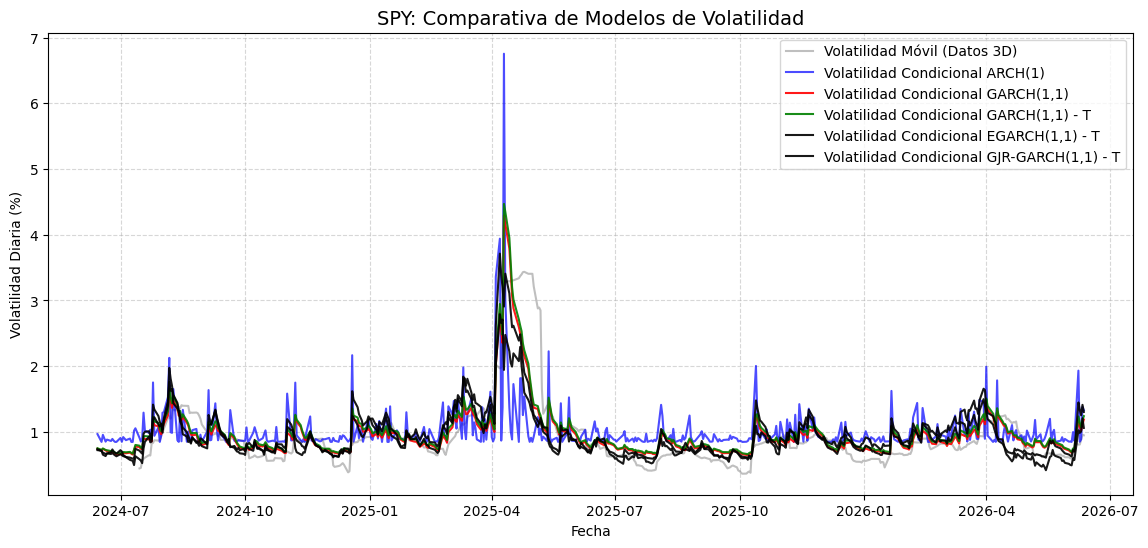

In [34]:
plt.figure(figsize=(14, 6))

# Volatilidad histórica móvil (la que usamos en la malla 3D, ajustada a escala diaria)
plt.plot(
    df.index,
    df["Volatility"] / np.sqrt(252) * 100,
    label="Volatilidad Móvil (Datos 3D)",
    alpha=0.5,
    color="gray",
)

# Volatilidad estimada por ARCH
plt.plot(
    df.index,
    df["ARCH_Volatility"],
    label="Volatilidad Condicional ARCH(1)",
    alpha=0.7,
    color="blue",
)

# Volatilidad estimada por GARCH
plt.plot(
    df.index,
    df["GARCH_Volatility"],
    label="Volatilidad Condicional GARCH(1,1)",
    alpha=0.9,
    color="red",
)

plt.plot(
    df.index,
    df["GARCH_t_Volatility"],
    label="Volatilidad Condicional GARCH(1,1) - T",
    alpha=0.9,
    color="green",
)


plt.plot(
    df.index,
    df["EGARCH_t_Volatility"],
    label="Volatilidad Condicional EGARCH(1,1) - T",
    alpha=0.9,
    color="black",
)

plt.plot(
    df.index,
    df["GJR-GARCH_t_Volatility"],
    label="Volatilidad Condicional GJR-GARCH(1,1) - T",
    alpha=0.9,
    color="black",
)


plt.title("SPY: Comparativa de Modelos de Volatilidad", fontsize=14)
plt.xlabel("Fecha")
plt.ylabel("Volatilidad Diaria (%)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


In [37]:
import pandas as pd

modelos = {
    'ARCH(1)': resultado_arch,
    'GARCH(1,1)': resultado_garch, 
    'GARCH-t': resultado_garch,
    'GJR-GARCH-t': resultado_gjr_t,
    'EGARCH-t': resultado_egarch_t
}

comparacion = pd.DataFrame({
    'LogLik': [m.loglikelihood for m in modelos.values()],
    'AIC': [m.aic for m in modelos.values()],
    'BIC': [m.bic for m in modelos.values()]
    ## 'ARCH-LM pval': [m.arch_lm_test(lags=5).pvalue for m in modelos.values()]
}, index=modelos.keys())

print(comparacion.round(3).sort_values('BIC'))

              LogLik       AIC       BIC
EGARCH-t    -613.219  1238.438  1263.725
GJR-GARCH-t -616.992  1245.984  1271.272
GARCH-t     -627.083  1264.166  1285.239
GARCH(1,1)  -627.083  1264.166  1285.239
ARCH(1)     -700.960  1407.920  1420.564


ARCH-LM Test
H0: Residuals are homoskedastic.
ARCH-LM Test
H1: Residuals are conditionally heteroskedastic.
Statistic: 66.2705
P-value: 0.0000
Distributed: <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001B2288F0AD0>


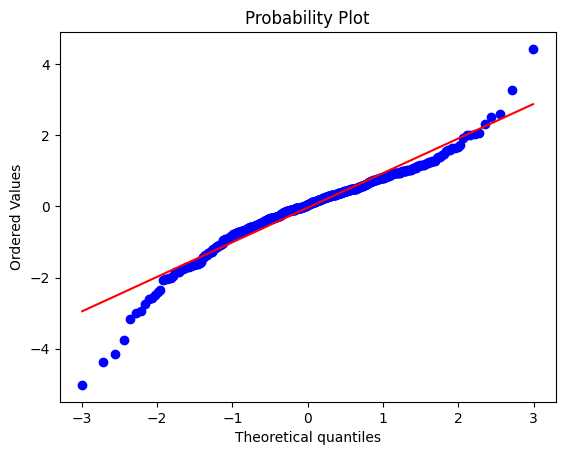

In [18]:
# 1. Chequear que no quede ARCH residual
print(resultado_garch.arch_lm_test(lags=5))

# 2. Ver residuos estandarizados
std_resid = resultado_garch.std_resid
import scipy.stats as stats
stats.jarque_bera(std_resid.dropna()) # Si p<0.05, no son normales

# 3. Q-Q plot para ver colas
import matplotlib.pyplot as plt
stats.probplot(std_resid, dist="norm", plot=plt)
plt.show()